## แบบฝึกหัดที่ 8

จากแบบฝึกหัดที่ 7 ให้นิสิตแสดงการ optimize 'n_neighbors' โดยมีรายละเอียดดังนี้  
1. ทำการแบ่ง train และ test set โดยใช้ train_test_split() ซึ่งมี argument test_size=0.3 และ random_state=1234
2. ทำการ optimize 'n_neighbors' โดยใช้ train set ทดสอบค่า 'n_neighbors' ในช่วง 1-30 และประสิทธิภาพที่ใช้วัดมาจาก Stratified 5-fold cross-validation (random_state=1234 ไม่มีการ repeat) โดยพิจารณาจาก auc score
3. สร้างโมเดล KNN จาก train set โดยใช้ 'n_neighbors' ที่ได้จากการ optimize นำโมเดลนี้มาทำนาย test set ในข้อ 1 และวัดประสิทธิภาพของโมเดลโดยแสดง confusion matrix แบบ heatmap และแสดงค่า accuracy, precision, recall, f1

ข้อมูล "Wholesale_customers_data.csv" มีรายละเอียดดังนี้:

**Attribute Information:**  
  
1) Fresh: annual spending (m.u.) on fresh products (Continuous);  
2) Milk: annual spending (m.u.) on milk products (Continuous);  
3) Grocery: annual spending (m.u.)on grocery products (Continuous);  
4) Frozen: annual spending (m.u.)on frozen products (Continuous)  
5) Detergents_paper: annual spending (m.u.) on detergents and paper products (Continuous)  
6) Delicassen: annual spending (m.u.)on and delicatessen products (Continuous);  
7) Channel<sup>*</sup>: customers channel - 1:Horeca (Hotel/Restaurant/Cafe) or 2:Retail channel (Nominal)  
8) Region: customers region - Lisnon, Oporto or Other (Nominal)

<sup>*</sup>Outcome/label variable  
monetary units = m.u.

โมเดลที่สร้างมีเป้าหมายเพื่อการทำนายตัวแปร Channel เช่นเดียวกับแบบฝึกหัดที่ 8

&nbsp;  
#### <font color="#1f7d02">*Read Dataset*</font>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier as knn
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/ThammakornS/ProgStat/main/dataset/Wholesale_customers_data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
df.Channel.value_counts()

,count
Channel,
1,298
2,142


In [4]:
df = df.astype({
    'Region': 'category',
})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Channel           440 non-null    int64   
 1   Region            440 non-null    category
 2   Fresh             440 non-null    int64   
 3   Milk              440 non-null    int64   
 4   Grocery           440 non-null    int64   
 5   Frozen            440 non-null    int64   
 6   Detergents_Paper  440 non-null    int64   
 7   Delicassen        440 non-null    int64   
dtypes: category(1), int64(7)
memory usage: 24.8 KB


In [5]:
categorical_cols = df.select_dtypes(include=['category']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
df

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region_2,Region_3
0,2,12669,9656,7561,214,2674,1338,0,1
1,2,7057,9810,9568,1762,3293,1776,0,1
2,2,6353,8808,7684,2405,3516,7844,0,1
3,1,13265,1196,4221,6404,507,1788,0,1
4,2,22615,5410,7198,3915,1777,5185,0,1
...,...,...,...,...,...,...,...,...,...
435,1,29703,12051,16027,13135,182,2204,0,1
436,1,39228,1431,764,4510,93,2346,0,1
437,2,14531,15488,30243,437,14841,1867,0,1
438,1,10290,1981,2232,1038,168,2125,0,1


&nbsp;  
#### <font color="#1f7d02">*Create feature and label data*</font>

In [ ]:
X = df.loc[:,~(df.columns=='Channel')]
X

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region_2,Region_3
0,12669,9656,7561,214,2674,1338,0,1
1,7057,9810,9568,1762,3293,1776,0,1
2,6353,8808,7684,2405,3516,7844,0,1
3,13265,1196,4221,6404,507,1788,0,1
4,22615,5410,7198,3915,1777,5185,0,1
...,...,...,...,...,...,...,...,...
435,29703,12051,16027,13135,182,2204,0,1
436,39228,1431,764,4510,93,2346,0,1
437,14531,15488,30243,437,14841,1867,0,1
438,10290,1981,2232,1038,168,2125,0,1


In [ ]:
y = df['Channel']
y

,Channel
0,2
1,2
2,2
3,1
4,2
...,...
435,1
436,1
437,2
438,1


In [ ]:
y.value_counts()

,count
Channel,
1,298
2,142


&nbsp;  
#### <font color="#1f7d02">*Train Test Split*</font>

In [ ]:
# Your code (use random_state=1234)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=1234)

In [ ]:
X_train.shape

(308, 8)

In [ ]:
X_test.shape

(132, 8)

In [ ]:
y_train.value_counts()

,count
Channel,
1,211
2,97


In [ ]:
y_test.value_counts()

,count
Channel,
1,87
2,45


&nbsp;  
#### <font color="#1f7d02">*Feature Data Scaling*</font>

In [ ]:
# Your code

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train) #Scaling parameters must based on training data.

X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

In [ ]:
X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)

In [ ]:
X_train_sc

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region_2,Region_3
0,0.389931,0.064417,0.078931,0.100220,0.008769,0.022528,0.0,1.0
1,0.040126,0.083044,0.149962,0.003238,0.218744,0.058010,0.0,0.0
2,0.358449,0.018981,0.020953,0.039500,0.004924,0.027743,0.0,1.0
3,0.036558,0.033659,0.056717,0.091706,0.019229,0.028306,0.0,0.0
4,0.093187,0.013031,0.032023,0.012706,0.008622,0.023759,0.0,1.0
...,...,...,...,...,...,...,...,...
303,0.025618,0.011383,0.056296,0.022191,0.000049,0.027639,0.0,0.0
304,0.006401,0.141852,0.124266,0.011687,0.137370,0.004610,0.0,1.0
305,0.279009,0.026660,0.070567,0.014399,0.019792,0.038611,1.0,0.0
306,0.158932,0.384938,0.427811,0.077306,0.475382,0.059804,0.0,0.0


In [ ]:
X_train_sc.std(numeric_only=True)

,0
Fresh,0.165813
Milk,0.110235
Grocery,0.106447
Frozen,0.088077
Detergents_Paper,0.119619
Delicassen,0.065433
Region_2,0.292521
Region_3,0.444412


In [ ]:
X_test_sc = pd.DataFrame(X_test_sc, columns=X_test.columns)

In [ ]:
X_test_sc.std(numeric_only=True)

,0
Fresh,0.165664
Milk,0.072885
Grocery,0.092747
Frozen,0.056183
Detergents_Paper,0.110334
Delicassen,0.039532
Region_2,0.344482
Region_3,0.464505


&nbsp;  
#### <font color="#1f7d02">*Evaluated KNN model on train set when n_neighbors = 1-30 by using stratified 5-fold cv*</font>

In [ ]:
# Your code

\
Set range of 'n_neighbors' to be tested:

In [ ]:
ks = range(1,31)

\
Configure cv:

In [ ]:
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=1234)

\
Perform cv for each 'n_neighbors':

In [ ]:
perf = {}
perf['n_neighbors'] = []
perf['acc'] = []
perf['precision'] = []
perf['recall'] = []
perf['f1'] = []
perf['auc'] = []

for k in ks:
    model_knn = knn(n_neighbors=k)
    y_pred = cross_val_predict(estimator=model_knn,
                               X=X_train_sc,
                               y=y_train,
                               cv=skf) # Use stratified KFOLD
    acc = metrics.accuracy_score(y_train, y_pred)
    precision = metrics.precision_score(y_train, y_pred, average='weighted')
    recall = metrics.recall_score(y_train, y_pred, average='weighted')
    f1 = metrics.f1_score(y_train, y_pred, average='weighted')
    auc = metrics.roc_auc_score(y_train, y_pred)

    perf['n_neighbors'].append(k)
    perf['acc'].append(acc)
    perf['precision'].append(precision)
    perf['recall'].append(recall)
    perf['f1'].append(f1)
    perf['auc'].append(auc)

perf = pd.DataFrame(perf)
perf.sort_values(by='auc', ascending=False).head()

,n_neighbors,acc,precision,recall,f1,auc
2,3,0.918831,0.918433,0.918831,0.917704,0.893414
4,5,0.918831,0.918433,0.918831,0.917704,0.893414
8,9,0.918831,0.918820,0.918831,0.917423,0.890629
6,7,0.915584,0.915243,0.915584,0.914268,0.888259
3,4,0.918831,0.919396,0.918831,0.917129,0.887844


&nbsp;  
#### <font color="#1f7d02">*Plot performance scores for each 'n_neighbors'*</font>

In [ ]:
# Your code

In [ ]:
df_forPlot = pd.melt(perf,
                     value_vars = ['acc', 'precision', 'recall', 'f1', 'auc'],
                     id_vars = ['n_neighbors'],
                     var_name = 'Metric',
                     value_name = 'Score')

Text(0.5, 1.0, '5-fold cv performance scores at different n_neighbors')

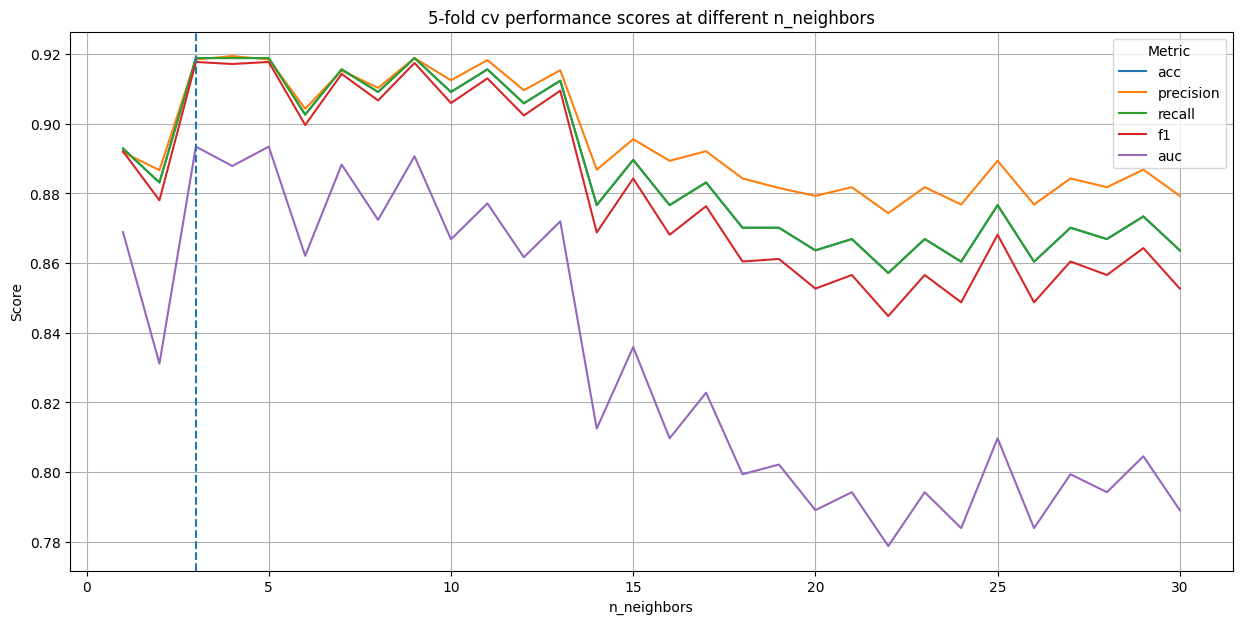

In [ ]:
fig, ax = plt.subplots(figsize=(15, 7))
sns.lineplot(data = df_forPlot,
             x = 'n_neighbors',
             y = 'Score',
             hue = 'Metric',
             ax=ax)
plt.grid()
plt.axvline(x=3, ls="--")
plt.title('5-fold cv performance scores at different n_neighbors')

\
If we focus on auc, then we select n_neighbors=19

&nbsp;  
#### <font color="#1f7d02">*Use KNN model with optimized 'n_neighbors' to predict test set*</font>

In [ ]:
# Your code

\
Create KNN model using n_neighbors=19 and fit on train data

In [ ]:
model_knn = knn(n_neighbors=3)
model_knn.fit(X=X_train_sc, y=y_train)

KNeighborsClassifier(n_neighbors=3)

\
Use above knn model (optimized n_neighbors) to predict test set

In [ ]:
y_pred_test = model_knn.predict(X_test_sc)

\
Evaluate model performance scores based on test set

In [ ]:
acc = metrics.accuracy_score(y_test, y_pred_test)
precision = metrics.precision_score(y_test, y_pred_test, average='weighted')
recall = metrics.recall_score(y_test, y_pred_test, average='weighted')
f1 = metrics.f1_score(y_test, y_pred_test, average='weighted')
auc = metrics.roc_auc_score(y_test, y_pred_test)

print(f"Test set performance scores:\n"
      f"accuracy: {acc:.2f}\n"
      f"precision: {precision:.2f}\n"
      f"recall: {recall:.2f}\n"
      f"f1: {f1:.2f}\n"
      f"auc: {auc:.2f}\n"
     )

Test set performance scores:
accuracy: 0.88
precision: 0.88
recall: 0.88
f1: 0.88
auc: 0.87



In [ ]:
conf_mat = metrics.confusion_matrix(y_test, y_pred_test, labels=[1, 2])
conf_mat

array([[78,  9],
       [ 7, 38]])

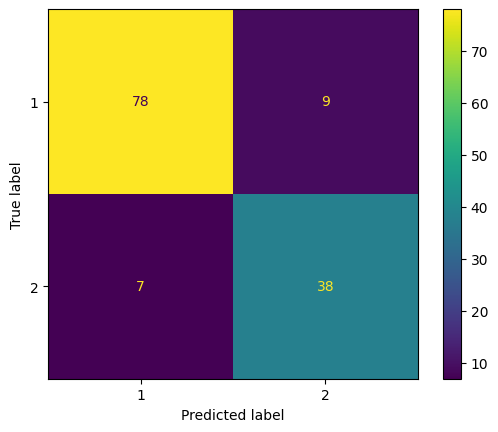

In [ ]:
metrics.ConfusionMatrixDisplay(conf_mat,
                               display_labels=[1, 2]).plot()

In [ ]:
print(metrics.classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           1       0.92      0.90      0.91        87
           2       0.81      0.84      0.83        45

    accuracy                           0.88       132
   macro avg       0.86      0.87      0.87       132
weighted avg       0.88      0.88      0.88       132

